# Mini-Projekt: Image Classification mit Python
Ziel:

Ein kleines Deep Learning Modell trainieren, das Bilder erkennt.

Dataset: Fashion-MNIST

Das sind Bilder von:

* Schuhe

* T-Shirts

* Taschen

* Hosen

In [1]:
import tensorflow as tf
print(tf.__version__)

I0000 00:00:1773094315.682450    1850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773094315.689045    1850 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773094316.329826    1850 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773094318.079699    1850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

2.21.0


In [2]:
#Bibliotheken importieren
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [15]:
#Dataset laden
fashion_mnist = keras.datasets.fashion_mnist

(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [11]:
#Daten normalisieren: das hilft dem Neural Network besser zu lernen
train_images = train_images / 255.0
test_images = test_images / 255.0

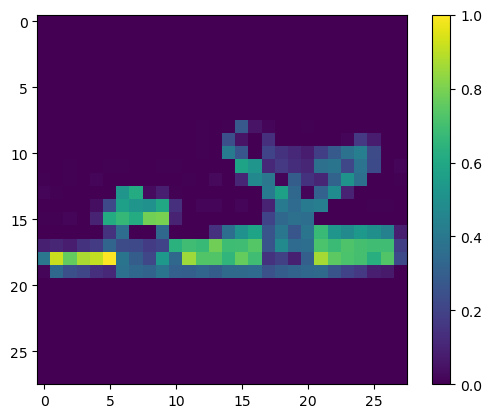

In [12]:
#Beispielbild anzeigen
plt.imshow(train_images[-1])
plt.colorbar()
plt.show()

In [13]:
#Neural Network erstellen
"""
Das Model hat: 
* Input layer
* Hidden layer
* Output layer
"""

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [16]:
#Model training
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7036 - loss: 3.5036 
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7747 - loss: 0.6573
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8036 - loss: 0.5700
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8175 - loss: 0.5324
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8243 - loss: 0.5172


In [17]:
#Modell Testen
"""
Accuracy kommt typischerweise: 
Accuracy = 88-90 %
"""
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8123 - loss: 0.5740
Test accuracy: 0.8123000264167786


In [20]:
#Vorhersage machen
"""
Das Modell sagt jetzt, welches Objekt im Bild ist.
"""
predictions = model.predict(test_images)

print(predictions[-1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step
[1.6394411e-08 3.1727141e-13 2.0708510e-16 2.0601986e-08 1.7276895e-11
 6.8307424e-01 1.8741779e-10 3.1572428e-01 3.0379544e-04 8.9770992e-04]
